In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Flatten, Dense, Dropout

2026-02-24 22:25:51.341209: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [15]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
# ==========================================
# 1. CONFIGURACIÓN (MODO AHORRO DE MEMORIA)
# ==========================================
filename = 'N-CMAPSS_DS08a-009.h5' 
WINDOW_SIZE = 50   
BATCH_SIZE = 512
EPOCHS = 15

# --- PARÁMETROS DE REDUCCIÓN ---
# Usar solo el 30% de los motores disponibles para entrenar (0.1 = 10%, 1.0 = 100%)
TRAIN_RATIO = 0.3  

# Salto al crear ventanas (Downsampling). 
# 1 = toma todas las ventanas posibles (máxima memoria).
# 10 = toma 1 ventana cada 10 segundos. Reduce el tamaño del dataset en 10x.
WINDOW_STEP = 10  

def load_data(filepath):
    with h5py.File(filepath, 'r') as hdf:
        # Development set (Train)
        W_dev = np.array(hdf.get('W_dev'))
        X_s_dev = np.array(hdf.get('X_s_dev'))
        X_v_dev = np.array(hdf.get('X_v_dev'))
        Y_dev = np.array(hdf.get('Y_dev'))
        A_dev = np.array(hdf.get('A_dev')) 
        
        # Test set
        W_test = np.array(hdf.get('W_test'))
        X_s_test = np.array(hdf.get('X_s_test'))
        X_v_test = np.array(hdf.get('X_v_test'))
        Y_test = np.array(hdf.get('Y_test'))
        A_test = np.array(hdf.get('A_test'))
        
        # Corrección de lectura de variables
        A_var = np.array(hdf.get('A_var'))
        A_var = list(np.array(A_var, dtype='U20'))
        
    return (W_dev, X_s_dev, X_v_dev, Y_dev, A_dev), (W_test, X_s_test, X_v_test, Y_test, A_test), A_var

print("Cargando datos...")
(train_W, train_Xs, train_Xv, train_Y, train_A), \
(test_W, test_Xs, test_Xv, test_Y, test_A), A_var = load_data(filename)

# ==========================================
# 2. REDUCCIÓN DE MOTORES (TRAIN)
# ==========================================
# ==========================================
# 2. SELECCIÓN DE UN SOLO MOTOR (AISLAMIENTO FÍSICO)
# ==========================================
# Identificar unidades únicas en entrenamiento
train_units = np.unique(train_A[:, 0])

# Seleccionamos ESTRICTAMENTE el primer motor para el entrenamiento
motor_aislado_train = train_units[0] 

print(f"Modo Depuración: Entrenando ÚNICAMENTE con la unidad: {motor_aislado_train}")

# Crear la máscara para filtrar solo los datos de ese motor
mask_train = (train_A[:, 0] == motor_aislado_train)

train_W_1 = train_W[mask_train]
train_Xs_1 = train_Xs[mask_train]
train_Xv_1 = train_Xv[mask_train]
train_Y_1 = train_Y[mask_train]
train_A_1 = train_A[mask_train]

# Preprocesamiento y Escalado (Se mantiene igual pero aplicado a train_1)
X_train_1 = np.concatenate((train_W_1, train_Xs_1, train_Xv_1), axis=1)
X_test = np.concatenate((test_W, test_Xs, test_Xv), axis=1)
# Asumiendo que ya instanciaste tu scaler = MinMaxScaler(...)
scaler = MinMaxScaler(feature_range=(-1, 1))
X_train_scaled = scaler.fit_transform(X_train_1) 
X_test_scaled = scaler.transform(X_test)
print(f"Forma de X_train (Unidad {motor_aislado_train}): {X_train_scaled.shape}")

# ==========================================
# 3. PREPROCESAMIENTO Y ESCALADO
# ==========================================
#X_train = np.concatenate((train_W, train_Xs, train_Xv), axis=1)
#X_test = np.concatenate((test_W, test_Xs, test_Xv), axis=1)

#scaler = MinMaxScaler(feature_range=(-1, 1))
#X_train_scaled = scaler.fit_transform(X_train)


print(f"Forma de X_train (reducido): {X_train_scaled.shape}")

Cargando datos...
Modo Depuración: Entrenando ÚNICAMENTE con la unidad: 1.0
Forma de X_train (Unidad 1.0): (321104, 32)
Forma de X_train (reducido): (321104, 32)


In [17]:
def create_windows(X, y, A, window_size, step=1, unit_col_index=0):
    unique_units = np.unique(A[:, unit_col_index])
    X_windows = []
    y_windows = []
    
    for unit in unique_units:
        idx = np.where(A[:, unit_col_index] == unit)[0]
        unit_X = X[idx, :]
        unit_y = y[idx]
        
        num_samples = len(unit_X)
        if num_samples < window_size:
            continue
            
        # APLICAMOS EL STEP AQUÍ PARA REDUCIR DATOS
        for i in range(0, num_samples - window_size + 1, step):
            X_windows.append(unit_X[i : i + window_size, :])
            y_windows.append(unit_y[i + window_size - 1])
            
    return np.array(X_windows), np.array(y_windows)

print("Generando ventanas para el motor aislado (Step=1)...")

# ALERTA: step=1 es mandatorio para mantener la derivada dh = -1
X_train_w, y_train_w = create_windows(X_train_scaled, train_Y_1, train_A_1, WINDOW_SIZE, step=1)

print(f"Input Shape Train Final (Secuencial puro): {X_train_w.shape}")



Generando ventanas para el motor aislado (Step=1)...
Input Shape Train Final (Secuencial puro): (321055, 50, 32)


In [32]:
import tensorflow as tf

class CustomRULLoss(tf.keras.losses.Loss):
    def __init__(self, a=0.1, lambda1=1.0, lambda2=0.001, name="custom_rul_loss", **kwargs):
        """
        Parámetros:
        a: Factor de forma de LINEX (controla qué tan rápido crece la exponencial).
        lambda1: Peso para la pérdida LINEX.
        lambda2: Peso para el Suavizado Temporal (Smoothness).
        """
        super().__init__(name=name, **kwargs)
        self.a = tf.constant(a, dtype=tf.float32)
        self.lambda1 = tf.constant(lambda1, dtype=tf.float32)
        self.lambda2 = tf.constant(lambda2, dtype=tf.float32)

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)

        # 1. L_mse: Error Cuadrático Medio
        mse_loss = tf.reduce_mean(tf.square(y_true - y_pred))

        # 2. L_linex: Función Linear-Exponencial
        d = y_pred - y_true
        
        # PREVENCIÓN DE OVERFLOW: Recortamos solo el techo positivo.
        # Si 'a' = 0.1, un max de 800 asegura exp(80), límite seguro de float32.
        # Por debajo no importa tanto recortar porque LINEX se vuelve lineal.
        d_clipped = tf.clip_by_value(d, clip_value_min=-5000.0, clip_value_max=800.0)
        
        # Fórmula matemática de LINEX: exp(a*d) - a*d - 1
        linex_loss = tf.exp(self.a * d_clipped) - (self.a * d_clipped) - 1.0
        mean_linex = tf.reduce_mean(linex_loss)

        # 3. L_smoothness: Regularización de Suavidad Temporal (Corregida)
        def compute_smoothness():
            # En lugar de forzar que la curva sea plana (dh = 0), 
            # forzamos a que la pendiente predicha imite a la pendiente real.
            
            dh_pred = y_pred[1:] - y_pred[:-1]
            dh_true = y_true[1:] - y_true[:-1]
            
            # Penalizamos la diferencia. El ruido de alta frecuencia morirá, 
            # pero la tendencia descendente natural se mantendrá intacta.
            return tf.reduce_mean(tf.square(dh_pred - dh_true))
        
        smoothness_loss = tf.cond(tf.shape(y_pred)[0] > 1, 
                                  compute_smoothness, 
                                  lambda: tf.constant(0.0, dtype=tf.float32))

        # Pérdida Total
        loss_total = mse_loss + (self.lambda1 * mean_linex) + (self.lambda2 * smoothness_loss)
        return loss_total

In [33]:
# When preparing your tf.data.Dataset or passing arrays to model.fit, 
# you MUST ensure that shuffle is turned off for the temporal smoothness to work correctly.

# Example configuration:
BATCH_SIZE = 256
EPOCHS = 10

# Assuming X_train_w and y_train_w are already prepared windowed sequences from Dataset 8
# Ensure they are sorted by engine unit and time cycle.

In [34]:
def build_cnn(input_shape):
    model = Sequential([
        tf.keras.Input(shape=input_shape),
        Conv1D(filters=32, kernel_size=3, activation='relu', padding='same'),
        Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
        Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
        Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
        Conv1D(filters=32, kernel_size=3, activation='relu', padding='same'),
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(1) # RUL Output
    ])
    return model

# From the context, Dataset 8 input shape involves sequence length 50 and 32 features
input_shape = (50, 32)
model = build_cnn(input_shape)
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_20 (Conv1D)              │ (None, 50, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_21 (Conv1D)              │ (None, 50, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_22 (Conv1D)              │ (None, 50, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_23 (Conv1D)              │ (None, 50, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_24 (Conv1D)              │ (None, 50, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,361 (653.75 KB)

 Trainable params: 167,361 (653.75 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
# Initialize loss with chosen lambda weights
# These values require hyperparameter tuning. If lambda2 is too high, the model will output a flat line.
loss_fn = CustomRULLoss(lambda1=0.5, lambda2=0.01)

model.compile(optimizer='adam', loss=loss_fn, metrics=['mae', 'mse'])

print("Starting training with Temporal Smoothness Regularization...")

# IMPORTANT: shuffle=False is strictly required to maintain the sequence order for the 'dh' calculation
history = model.fit(
    X_train_w, y_train_w,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    shuffle=False, 
    verbose=1
)

Starting training with Temporal Smoothness Regularization...
Epoch 1/10
1129/1129 ━━━━━━━━━━━━━━━━━━━━ 133s 113ms/step - loss: 731.2369 - mae: 8.5433 - mse: 233.3855 - val_loss: 15.7360 - val_mae: 3.3128 - val_mse: 15.6883
Epoch 2/10
1129/1129 ━━━━━━━━━━━━━━━━━━━━ 115s 102ms/step - loss: 125415022592.0000 - mae: 20.3123 - mse: 868.8453 - val_loss: 16.0942 - val_mae: 3.2741 - val_mse: 16.0449
Epoch 3/10
1129/1129 ━━━━━━━━━━━━━━━━━━━━ 140s 124ms/step - loss: 396.8612 - mae: 13.4176 - mse: 379.2899 - val_loss: 6.8889 - val_mae: 2.1106 - val_mse: 6.8696
Epoch 4/10
1129/1129 ━━━━━━━━━━━━━━━━━━━━ 120s 106ms/step - loss: 325.2640 - mae: 12.3520 - mse: 321.1849 - val_loss: 7.5102 - val_mae: 2.2125 - val_mse: 7.4889
Epoch 5/10
1129/1129 ━━━━━━━━━━━━━━━━━━━━ 111s 98ms/step - loss: 431.7495 - mae: 13.1310 - mse: 361.2476 - val_loss: 16.9250 - val_mae: 3.4516 - val_mse: 16.8736
Epoch 6/10
1129/1129 ━━━━━━━━━━━━━━━━━━━━ 114s 101ms/step - loss: 324.7827 - mae: 12.0534 - mse: 320.9265 - val_loss: 21.

In [36]:
# Evaluar ambos modelos en el set de test completo
y_pred_mse = model.predict(X_test_w, verbose=0)


rmse_mse = np.sqrt(mean_squared_error(y_test_w, y_pred_mse))


# Calcular el error promedio (Bias)
# Un error positivo significa que el modelo es conservador (predice RUL menor al real)
bias_mse = np.mean(y_test_w - y_pred_mse)


print(f"--- COMPARATIVA FINAL ---")
print(f"MSE Model   | RMSE: {rmse_mse:.4f} | Bias: {bias_mse:.4f}")


--- COMPARATIVA FINAL ---
MSE Model   | RMSE: 28.0693 | Bias: 21.3581


Generando comparativa para el Motor 13...


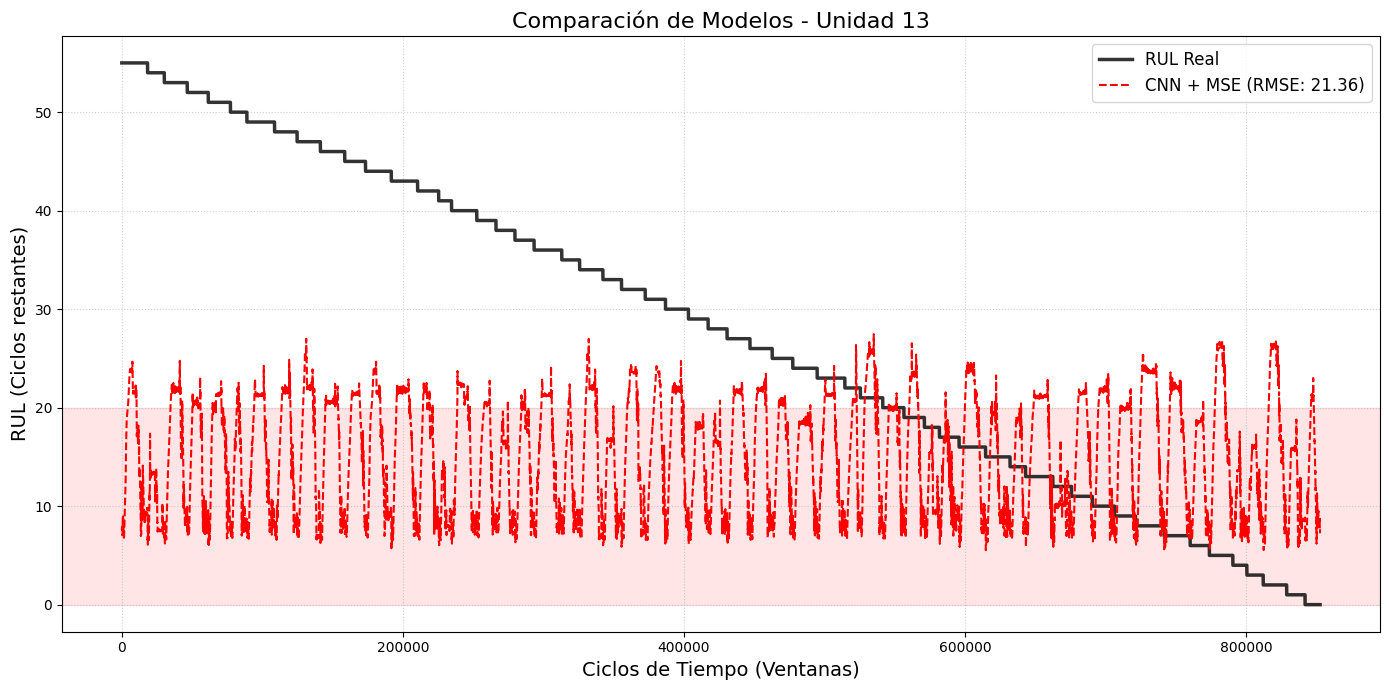

In [37]:
def comparar_resultados_motores(unit_id):
    """
    Grafica la comparación entre el modelo MSE (Original) y el modelo LINEX (Refinado)
    para una unidad específica del set de test.
    """
    print(f"Generando comparativa para el Motor {unit_id}...")
    
    # 1. Filtrar datos de la unidad elegida
    idx = np.where(test_A[:, 0] == unit_id)[0]
    
    if len(idx) == 0:
        print(f"Error: El motor {unit_id} no se encuentra en el set de Test.")
        return

    # 2. Extraer y preparar ventanas (paso 1 para máxima resolución)
    unit_X = X_test_scaled[idx]
    unit_y = test_Y[idx]
    
    # Reutilizamos la función create_windows que definimos antes
    X_w, y_real = create_windows(unit_X, unit_y, test_A[idx], WINDOW_SIZE, step=1)
    
    # 3. Realizar predicciones con ambos modelos
    # 'model' es el de MSE y 'model_linex' es el de LINEX
    pred_mse = model.predict(X_w, verbose=0)
   
    
    # 4. Calcular RMSE individual para el reporte en el título
    rmse_mse = np.sqrt(mean_squared_error(y_real, pred_mse))

    
    # 5. GRAFICAR
    plt.figure(figsize=(14, 7))
    
    # Línea Real
    plt.plot(y_real, label='RUL Real', color='black', linewidth=2.5, alpha=0.8)
    
    # Predicción MSE
    plt.plot(pred_mse, label=f'CNN + MSE (RMSE: {rmse_mse:.2f})', 
             color='red', linestyle='--', linewidth=1.5)
    
    # Estética de la gráfica
    plt.title(f'Comparación de Modelos - Unidad {unit_id}', fontsize=16)
    plt.xlabel('Ciclos de Tiempo (Ventanas)', fontsize=14)
    plt.ylabel('RUL (Ciclos restantes)', fontsize=14)
    plt.legend(loc='upper right', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.6)
    
    # Añadir una zona de "Falla Crítica" sombreada para mayor impacto visual
    plt.axhspan(0, 20, color='red', alpha=0.1, label='Zona Crítica')
    
    plt.tight_layout()
    plt.show()

# --- Ejecución para el motor 13 ---
comparar_resultados_motores(13)
